In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import gridspec
from pathlib import Path

from cleanup_ssps.sspspace import HexagonalSSPSpace
from cleanup_ssps.model import ResidualMLP
from cleanup_ssps.cleanup_methods import FlowMatching

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [3]:
def make_unitary(ssp):
    fssp = torch.fft.fft(ssp)
    eps = torch.tensor(1e-8, device=fssp.device, dtype=fssp.real.dtype)
    fssp = fssp / torch.maximum(torch.sqrt(fssp.real**2 + fssp.imag**2), eps)
    return torch.fft.ifft(fssp).real

In [202]:
def dot_product(v1, v2):
    """Rowwise dot product: v1, v2 -> (N,)"""
    return np.einsum('ij,ij->i', v1, v2)

def build_grid(ssp_dim=55, length_scale=0.1, bounds=np.array([[2,3],[2,3]]), num_points=50):
    """
    Builds x/y meshgrid and SSP encodings for visualization.
    """
    ssp_space = HexagonalSSPSpace(
        domain_dim=2, ssp_dim=ssp_dim,
        domain_bounds=bounds, length_scale=length_scale
    )
    x_grid, y_grid = np.meshgrid(np.linspace(bounds[0,0], bounds[0,1], num_points),
                                 np.linspace(bounds[1,0], bounds[1,1], num_points))
    grid_ssps, _ = ssp_space.get_sample_pts_and_ssps(num_points_per_dim=num_points, method="grid")
    grid_ssps = np.array(grid_ssps)
    return ssp_space, grid_ssps, x_grid, y_grid

def plot_ground_truth(z1, grid_ssps, x_grid, y_grid):
    """
    Visualize similarity map for a ground-truth SSP vector (z1).
    """
    state = z1.cpu().detach().numpy()

    ssp_space = HexagonalSSPSpace(
        domain_dim=2, ssp_dim=487,
        domain_bounds=np.array([[2,3],[2,3]]), length_scale=0.1
    )
    
    state = ssp_space.encode(np.array([[2.7, 2.8]]))  # just to initialize the space
    if state.ndim == 1:
        state = state[None, :]  # make it (1, D)
    sim = dot_product(np.repeat(state, grid_ssps.shape[0], axis=0), grid_ssps)
    sim = sim.reshape(x_grid.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(x_grid, y_grid, sim, levels=50)

    plt.xticks(np.linspace(x_grid.min(), x_grid.max(), 5), ['-1', '-0.5', '0', '0.5', '1'])
    plt.yticks(np.linspace(y_grid.min(), y_grid.max(), 5), ['-1', '-0.5', '0', '0.5', '1'])

    plt.colorbar()
    plt.title("Ground Truth (z1) Similarity Map")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

def plot_inference(traj, grid_ssps, x_grid, y_grid, num_steps=10, rows=2):
    """
    Visualizes similarity maps along a trajectory of SSPs.
    Automatically detects single-step vs multi-step cases.
    """
    if isinstance(traj, torch.Tensor):
        traj = traj.detach().cpu()

    # Handle both [D] and [T, D] tensors
    if traj.ndim == 1:
        traj = traj.unsqueeze(0)

    T = traj.shape[0]
    if T == 1:
        print("⚠️ Only one state found — showing single inference map.")
        step_idxs = [0]
    else:
        step_idxs = np.linspace(0, T - 1, min(num_steps, T), dtype=int)

    global_min, global_max = np.inf, -np.inf
    sims = []
    for i in step_idxs:
        state = traj[i].numpy()
        if state.ndim == 1:
            state = state[None, :]
        sim = dot_product(np.repeat(state, grid_ssps.shape[0], axis=0), grid_ssps)
        sim = sim.reshape(x_grid.shape)
        sims.append(sim)
        global_min = min(global_min, sim.min())
        global_max = max(global_max, sim.max())

    cols = int(np.ceil(len(step_idxs) / rows))
    fig = plt.figure(figsize=(4 * cols, 4 * rows))
    gs = gridspec.GridSpec(rows, cols + 1, width_ratios=[1] * cols + [0.05], wspace=0.3)
    axs = []

    for i in range(len(step_idxs)):
        ax = fig.add_subplot(gs[i // cols, i % cols])
        axs.append(ax)

    mappable = None
    for i, (ax, sim) in enumerate(zip(axs, sims)):
        mappable = ax.contourf(x_grid, y_grid, sim, levels=50, vmin=global_min, vmax=global_max)
        ax.set_title(f"Step {step_idxs[i]}")
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        
        # Relabel axes ticks from -1 to 1
        ax.set_xticks(np.linspace(x_grid.min(), x_grid.max(), 5))
        ax.set_xticklabels(['-1', '-0.5', '0', '0.5', '1'])
        ax.set_yticks(np.linspace(y_grid.min(), y_grid.max(), 5))
        ax.set_yticklabels(['-1', '-0.5', '0', '0.5', '1'])

    # Add colorbar
    cbar_ax = fig.add_subplot(gs[:, -1])
    fig.colorbar(mappable, cax=cbar_ax)
    plt.show()


In [203]:
def load_model(ckpt_path, ssp_dim, mode="flow"):
    """
    Loads either:
      - flow model (LoRA/CFM)  → mode="flow"
      - feedforward model      → mode="ff"
    """
    ckpt_path = Path(ckpt_path)
    if mode == "flow":
        model = ResidualMLP(ssp_dim, flow=True).to(DEVICE)
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=False))
        model.eval()
        wrapper = FlowMatching(model=model, sampling=ckpt_path.stem, device=DEVICE)
        return wrapper
    else:
        model = ResidualMLP(ssp_dim, flow=False).to(DEVICE)
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=False))
        model.eval()
        return model


Loaded SSP shape: torch.Size([1, 487])


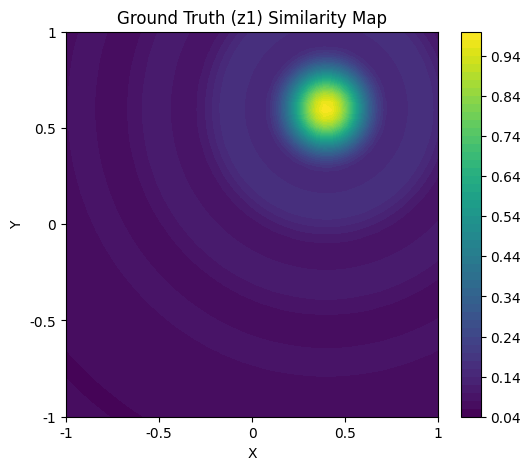

In [ ]:
ls = 0.1
dim = 487
file_path = f"/u1/khabashy/CleanupSSP/data/dim_{dim}_scale_{ls}/train/coordinate_ssps/coordinate_ssp_4036.npy"



z1 = np.load(file_path)
z1 = torch.tensor(z1, dtype=torch.float32).to(DEVICE)
if z1.ndim == 1:
    z1 = z1.unsqueeze(0)

ssp_space, grid_ssps, x_grid, y_grid = build_grid(ssp_dim=dim, length_scale=ls)

print("Loaded SSP shape:", z1.shape)


# --- VISUALIZE GROUND TRUTH ---
plot_ground_truth(z1, grid_ssps, x_grid, y_grid)


Trajectory shape: torch.Size([26, 487])


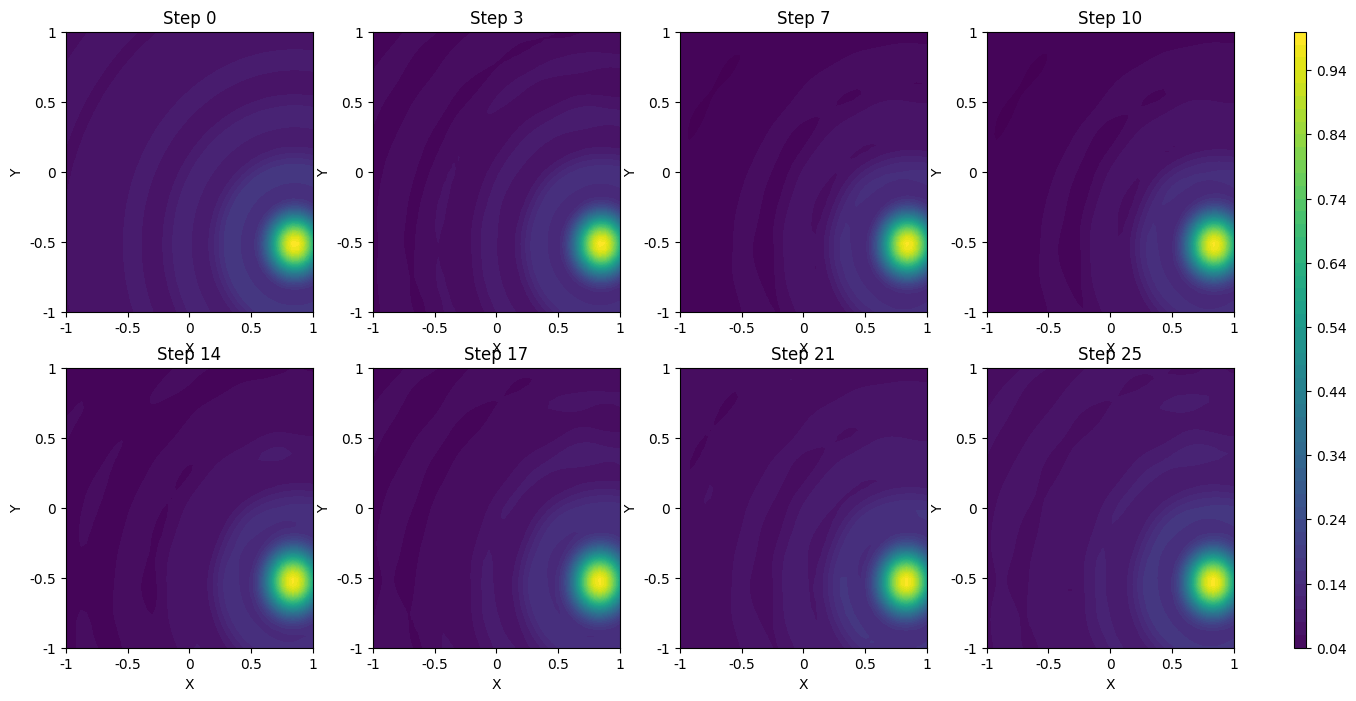

In [206]:
# --- RUN INFERENCE & VISUALIZE TRAJECTORY ---
# Change this to your checkpoint
ckpt_path = f"/u1/khabashy/CleanupSSP/trained_models/Hex/dim{dim}_ls{ls}/drift_geo_det.pt"

model = load_model(ckpt_path, dim, mode="flow")

# Construct corrupted input at desired SNR
snr = 1.
z_noise = torch.randn_like(z1)
z_noise = z_noise / z_noise.norm(dim=1, keepdim=True)
z_init = snr * z1 + (1 - snr) * z_noise
z_init = z_init / z_init.norm(dim=1, keepdim=True)

traj = model.sample_ode(z_init, N=25, use_sphere=True)

# If it's a list of tensors → stack
if isinstance(traj, list):
    traj = torch.stack(traj, dim=0)
# If there's an extra batch dimension → squeeze it out
if traj.ndim == 3 and traj.shape[1] == 1:
    traj = traj.squeeze(1)

print("Trajectory shape:", traj.shape)

plot_inference(traj, grid_ssps, x_grid, y_grid, num_steps=8, rows=2)


In [254]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_feedforward_inference(z0, z1_pred, grid_ssps, x_grid, y_grid):
    """
    Visualize the noisy input, model prediction, and ground-truth SSP similarity maps side-by-side.
    """
    # def compute_map(vec):
    #     if isinstance(vec, torch.Tensor):
    #         vec = vec.detach().cpu().numpy()
    #     if vec.ndim == 1:
    #         vec = vec[None, :]
    #     # Assuming dot_product is defined elsewhere in your code
    #     sim = np.dot(np.repeat(vec, grid_ssps.shape[0], axis=0), grid_ssps.T) 
    #     # Note: I used np.dot above as a placeholder for your dot_product function
    #     return sim.reshape(x_grid.shape)
    
    def compute_map(vec):
        if isinstance(vec, torch.Tensor):
            vec = vec.detach().cpu().numpy()
            
        # Ensure vec is a flat vector (D,)
        vec = vec.flatten()
        
        # Calculate dot product between every grid point and the vector
        # grid_ssps shape is likely (2500, D)
        # vec shape is (D,)
        # Result shape is (2500,)
        sim = grid_ssps @ vec 
        
        return sim.reshape(x_grid.shape)

    maps = {
        "Noisy Input (z0)": compute_map(z0),
        "Feedforward Model Prediction (ẑ1)": compute_map(z1_pred),
    }


    vmin = min(m.min() for m in maps.values())
    vmax = max(m.max() for m in maps.values())

    fig = plt.figure(figsize=(10, 5))
    
    # CHANGE 1: Only create 2 columns. We don't need a dedicated column for cbar anymore.
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)

    axs = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
    mappable = None
    
    for ax, (title, sim) in zip(axs, maps.items()):
        mappable = ax.contourf(x_grid, y_grid, sim, levels=50, vmin=vmin, vmax=vmax)
        # ax.set_title(title)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_aspect("equal") # This is what was causing the height mismatch
        ax.set_xlim(x_grid.min(), x_grid.max())
        ax.set_ylim(y_grid.min(), y_grid.max())

        ax.set_xticks(np.linspace(x_grid.min(), x_grid.max(), 5))
        ax.set_xticklabels(['-1', '-0.5', '0', '0.5', '1'])
        ax.set_yticks(np.linspace(y_grid.min(), y_grid.max(), 5))
        ax.set_yticklabels(['-1', '-0.5', '0', '0.5', '1'])

    # CHANGE 2: Attach colorbar to the RIGHT plot (axs[1])
    # This divider finds the exact height of the plot after 'aspect=equal' is applied
    divider = make_axes_locatable(axs[1])
    
    # Create a new axis 'cax' to the right of the plot.
    # size="5%" means the bar is 5% of the plot width.
    cax = divider.append_axes("right", size="5%", pad=0.1)
    
    fig.colorbar(mappable, cax=cax)
    
    plt.show()

/tmp/ipykernel_1428862/3481067418.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ff.load_state_dict(torch.load(f"/u1/khabashy/CleanupSSP/trained_models/Hex/dim{di

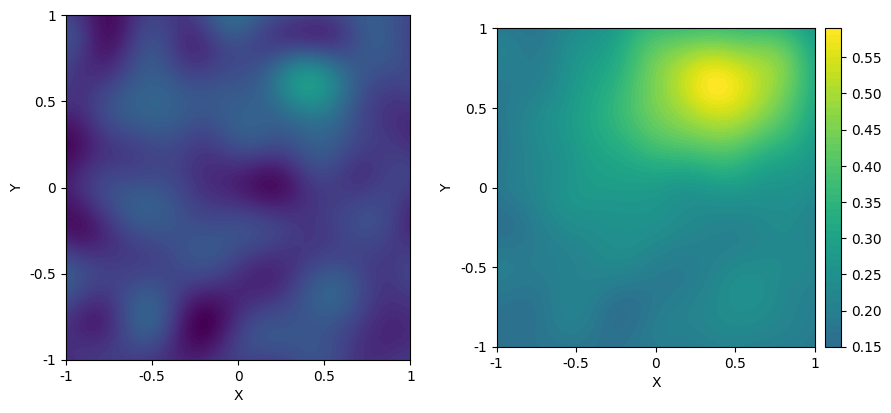

In [255]:
# Load a feedforward model
model_ff = ResidualMLP(dim, flow=False).to(DEVICE)
model_ff.load_state_dict(torch.load(f"/u1/khabashy/CleanupSSP/trained_models/Hex/dim{dim}_ls{ls}/feedforward_ot.pt", map_location=DEVICE))
model_ff.eval()


ssp_space = HexagonalSSPSpace(
        domain_dim=2, ssp_dim=487,
        domain_bounds=np.array([[2,3],[2,3]]), length_scale=0.1
    )
    
state = ssp_space.encode(np.array([[2.7, 2.8]]))  # just to initialize the space
if state.ndim == 1:
    state = state[None, :]  # make it (1, D)
z1 = torch.tensor(state, dtype=torch.float32).to(DEVICE)

noise = torch.randn_like(z1)
snr = .85
z0 = snr * z1 + (1 - snr) * noise
z0 = z0 / z0.norm(dim=1, keepdim=True)

# Model inference
with torch.no_grad():
    z1_pred = model_ff(z0)
    out = z1_pred
    # out = make_unitary(z1_pred)
    out = out / out.norm(dim=1, keepdim=True)

# Visualize
plot_feedforward_inference(z0, out, grid_ssps, x_grid, y_grid)
